In [4]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET, ps_slowdown = 2)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm16 = trex.run()
sample = Sample(en={"uniform": (40, 50)})
res_inelastic_rrm16 = trex.run(sample)
trex.choppers

{'Bandwidth Chopper 1': Chopper(axle_position=<scipp.Variable> ()    vector3              [m]  (0, -0.3075, 31.964), frequency=<scipp.Variable> ()    float64             [Hz]  14, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  75.7597, slit_begin=<scipp.Variable> (cutouts: 1)    float64            [deg]  [-30.7], slit_end=<scipp.Variable> (cutouts: 1)    float64            [deg]  [30.7], slit_height=<scipp.Variable> (cutouts: 1)    float64              [m]  [0.35], radius=<scipp.Variable> ()    float64              [m]  0.35),
 'Bandwidth Chopper 2': Chopper(axle_position=<scipp.Variable> ()    vector3              [m]  (0, -0.3075, 39.987), frequency=<scipp.Variable> ()    float64             [Hz]  14, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  92.6249, slit_begin=<scipp.Variable> (cutouts: 1)    float64            [deg]  [-31.65], sli

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_92228/3562812820.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


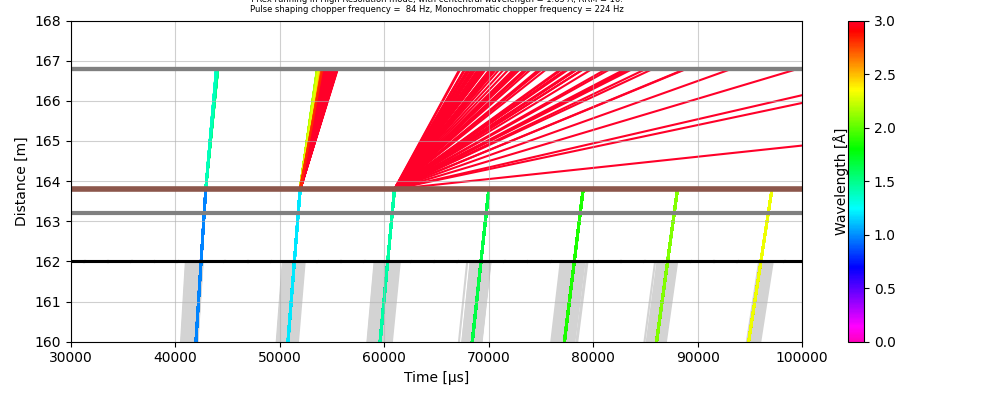

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm16.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=3
)
ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

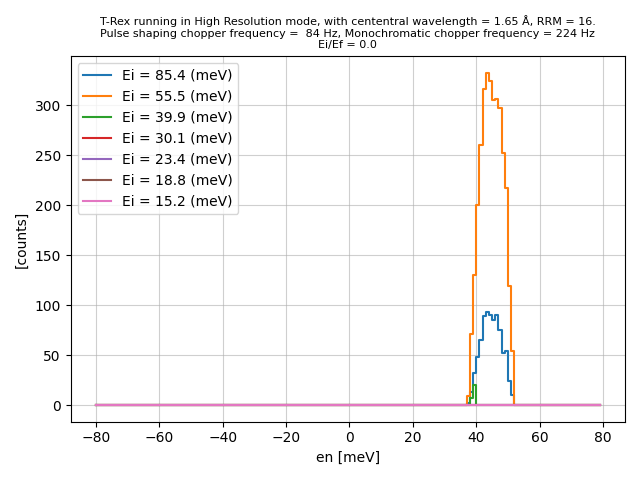

In [6]:
import plopp as pp

ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm16)
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
trex.wrap_frame(res_inelastic_rrm16)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()